## 1: Import Libraries
We import deep learning libraries for building the 1D-CNN.
- numpy and pandas: for data handling
- tensorflow/keras: for building and training the CNN
- sklearn: for splitting data and evaluation metrics
- matplotlib: for plotting training results

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

print(f" All libraries imported")
print(f"TensorFlow version: {tf.__version__}")

 All libraries imported
TensorFlow version: 2.21.0


## 2: Load and Prepare ECG Data for CNN
We load the raw ECG windows saved on Day 2.
CNN needs the data in 3D shape: (samples, timesteps, channels)
So we reshape from (2754, 7500) to (2754, 7500, 1).
We also split into 80% training and 20% testing.

In [3]:
SAVE_PATH = r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman"

X_ecg = np.load(f"{SAVE_PATH}\\X_ecg.npy")
y = np.load(f"{SAVE_PATH}\\y_labels.npy")

# Normalize the ECG signal
X_ecg = (X_ecg - np.mean(X_ecg, axis=1, keepdims=True)) / (np.std(X_ecg, axis=1, keepdims=True) + 1e-8)

# Reshape for CNN: (samples, timesteps, channels)
X_cnn = X_ecg.reshape(X_ecg.shape[0], X_ecg.shape[1], 1)

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data prepared!")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")
print(f"\nTrain — Normal: {np.sum(y_train==0)} | Apnea: {np.sum(y_train==1)}")
print(f"Test  — Normal: {np.sum(y_test==0)}  | Apnea: {np.sum(y_test==1)}")

Data prepared!
X_train shape : (2203, 7500, 1)
X_test shape  : (551, 7500, 1)
y_train shape : (2203,)
y_test shape  : (551,)

Train — Normal: 1911 | Apnea: 292
Test  — Normal: 478  | Apnea: 73


## 3: Build the 1D-CNN Architecture
A 1D-CNN (1D Convolutional Neural Network) learns patterns
directly from raw ECG signal without manual feature engineering.
It slides filters across the signal to detect heartbeat patterns
that differ between apnea and normal windows.
Our architecture:
- 3 Convolutional blocks with increasing filters (32, 64, 128)
- Each block has Conv1D + BatchNorm + MaxPooling + Dropout
- Global Average Pooling to reduce dimensions
- Dense layers for final classification

In [4]:
def build_cnn(input_shape):
    model = keras.Sequential([
        # Block 1
        layers.Conv1D(32, kernel_size=7, activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.2),
        
        # Block 2
        layers.Conv1D(64, kernel_size=5, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.2),
        
        # Block 3
        layers.Conv1D(128, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.3),
        
        # Classification head
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_cnn((7500, 1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 7494, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7494, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1873, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1873, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1869, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1869, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 467, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 467, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 465, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 465, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 116, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 116, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,481 (173.75 KB)

 Trainable params: 44,033 (172.00 KB)

 Non-trainable params: 448 (1.75 KB)

## 4: Train the 1D-CNN
We compile the model with Adam optimizer and binary
crossentropy loss since this is a binary classification.
We use class weights to handle the class imbalance —
apnea windows are rarer so we give them more weight.
We train for 20 epochs with early stopping to prevent
overfitting.

In [5]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# Early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=5, restore_best_weights=True, mode='max')

# Train
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {0: np.float64(0.576399790685505), 1: np.float64(3.7722602739726026)}
Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 68s 737ms/step - accuracy: 0.6046 - auc: 0.7110 - loss: 0.6208 - val_accuracy: 0.6788 - val_auc: 0.8111 - val_loss: 0.6619
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 53s 771ms/step - accuracy: 0.6800 - auc: 0.7883 - loss: 0.5531 - val_accuracy: 0.2759 - val_auc: 0.8338 - val_loss: 0.8600
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 60s 871ms/step - accuracy: 0.6941 - auc: 0.8088 - loss: 0.5371 - val_accuracy: 0.2051 - val_auc: 0.8338 - val_loss: 1.0560
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 53s 766ms/step - accuracy: 0.7131 - auc: 0.8122 - loss: 0.5337 - val_accuracy: 0.4138 - val_auc: 0.8482 - val_loss: 1.0766
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.7249 - auc: 0.8229 - loss: 0.5241 - val_accuracy: 0.4936 - val_auc: 0.8712 - val_loss: 0.8455
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 51s 732ms/step - accuracy: 0.7367 - auc: 0.8324 - loss: 0.5105 - val_accur

## 5: Evaluate the CNN and Plot Training History
We evaluate the trained model on the test set and plot
the training curves showing how accuracy and AUC improved
over epochs. This tells us if the model learned well.

CNN Evaluation on Test Set:

              precision    recall  f1-score   support

      Normal       0.96      0.89      0.92       478
       Apnea       0.50      0.74      0.60        73

    accuracy                           0.87       551
   macro avg       0.73      0.81      0.76       551
weighted avg       0.90      0.87      0.88       551



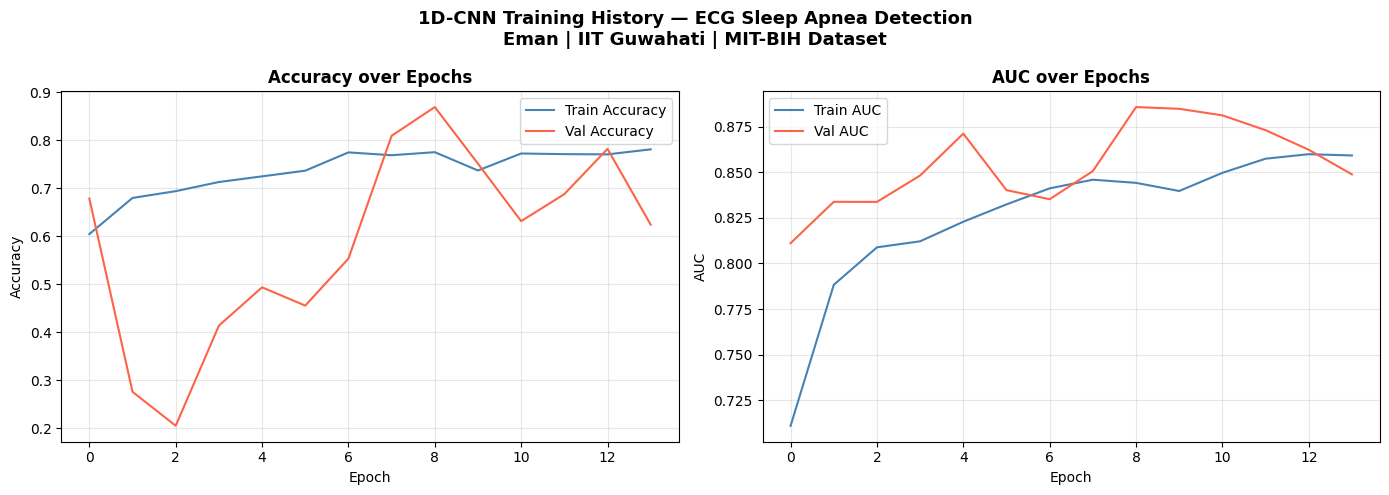

Plot saved


In [6]:
# Evaluate on test set
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("CNN Evaluation on Test Set:")
print(f"\n{classification_report(y_test, y_pred, target_names=['Normal', 'Apnea'])}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("1D-CNN Training History — ECG Sleep Apnea Detection\nEman | IIT Guwahati | MIT-BIH Dataset",
             fontsize=13, fontweight='bold')

# Accuracy
ax1 = axes[0]
ax1.plot(history.history['accuracy'], color='steelblue', label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], color='tomato', label='Val Accuracy')
ax1.set_title("Accuracy over Epochs", fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# AUC
ax2 = axes[1]
ax2.plot(history.history['auc'], color='steelblue', label='Train AUC')
ax2.plot(history.history['val_auc'], color='tomato', label='Val AUC')
ax2.set_title("AUC over Epochs", fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUC")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman\ecg_cnn_training_plot.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## 6: Save CNN Predictions as a Feature
The CNN output probability is itself a powerful feature.
We run the CNN on ALL 2754 windows and save the predicted
probability of apnea for each window.
On Day 5 this CNN probability will be added as an extra
feature alongside the HRV features in the merged table.

In [7]:
# Get CNN predictions on all data (not just test)
X_all_cnn = X_ecg.reshape(X_ecg.shape[0], X_ecg.shape[1], 1)
cnn_probs = model.predict(X_all_cnn, verbose=0).flatten()

# Save CNN probabilities
SAVE_PATH = r"C:\Users\EmaSk\Desktop\sleep-apnea-detection\eman"
np.save(f"{SAVE_PATH}\\cnn_probs.npy", cnn_probs)

print(f"CNN probabilities saved")
print(f"Shape        : {cnn_probs.shape}")
print(f"Min prob     : {cnn_probs.min():.4f}")
print(f"Max prob     : {cnn_probs.max():.4f}")
print(f"Mean prob    : {cnn_probs.mean():.4f}")
print(f"\nSample — first 5 probabilities:")
for i in range(5):
    print(f"  Window {i}: prob={cnn_probs[i]:.4f} | true label={y[i]}")

CNN probabilities saved
Shape        : (2754,)
Min prob     : 0.0055
Max prob     : 0.9369
Mean prob    : 0.3083

Sample — first 5 probabilities:
  Window 0: prob=0.8834 | true label=1
  Window 1: prob=0.8729 | true label=1
  Window 2: prob=0.9110 | true label=1
  Window 3: prob=0.9068 | true label=0
  Window 4: prob=0.9048 | true label=0
